# Importancia de variables de los modelos — Actividad 4

Este notebook carga las salidas de **Random Forest**, **DNN**, **SVM Nyström-RBF** y **XGBoost**, y produce gráficos individuales y comparaciones por rango.

Las magnitudes crudas no se comparan directamente porque tienen significados distintos:

- **RF:** disminución media de impureza del bosque seleccionado.
- **DNN:** caída de `f1_macro` en el holdout espacial al permutar una variable; incluye desviación estándar de 5 repeticiones.
- **SVM Nyström-RBF:** caída de `f1_macro` en el mismo holdout al permutar una variable; se calcula una vez y se guarda en caché.
- **XGBoost:** importancia nativa del modelo GPU seleccionado.
- **SVM lineal:** sus coeficientes se muestran aparte como diagnóstico complementario y no sustituyen la importancia de la SVM seleccionada.


In [1]:
from pathlib import Path
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib_inline.backend_inline import set_matplotlib_formats
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.metrics import f1_score

%matplotlib inline
set_matplotlib_formats("svg")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)


def find_repo_root(start: Path | None = None) -> Path:
    """Encuentra la raíz aunque el kernel inicie en el repo o en notebooks/."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del repositorio.")


REPO_ROOT = find_repo_root()
OUTPUT_DIR = REPO_ROOT / "data" / "processed" / "a4_model_feature_importance"
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 20
UNION_TOP_N = 10

PATHS = {
    "RF": REPO_ROOT / "data/processed/a4_7_rf_gridsearch_spatial_validation/tables/feature_importance.csv",
    "DNN": REPO_ROOT / "data/processed/a4_8_dnn_permutation_importance/tables/dnn_permutation_importance.csv",
    "XGBoost": REPO_ROOT / "data/processed/a4_9_xgboost_gpu/03_train_xgboost_gridsearch/tables/xgboost_gpu_feature_importance.csv",
    "SVM_lineal": REPO_ROOT / "data/processed/a4_8_svm/03_train_linear_svm_gridsearch/tables/linear_svm_feature_coefficients.csv",
    "SVM_model": REPO_ROOT / "data/processed/a4_8_svm/04_train_nystroem_rbf_svm/models/nystroem_rbf_svm_id_1_propuesta_best_development.joblib",
    "SVM_encoder": REPO_ROOT / "data/processed/a4_8_svm/04_train_nystroem_rbf_svm/models/nystroem_rbf_svm_id_1_propuesta_label_encoder.joblib",
    "SVM_features": REPO_ROOT / "data/processed/a4_8_svm/01_prepare_dataset/tables/svm_selected_feature_columns.txt",
    "SVM_independent": REPO_ROOT / "data/processed/a4_8_svm/02_spatial_splits/tables/svm_independent_validation_dataset.parquet",
}

SVM_PERMUTATION_PATH = TABLES_DIR / "svm_nystroem_rbf_permutation_importance.csv"
SVM_PERMUTATION_REPEATS_PATH = TABLES_DIR / "svm_nystroem_rbf_permutation_repeats.csv"

missing = {name: path for name, path in PATHS.items() if not path.is_file()}
if missing:
    detail = "\n".join(f"- {name}: {path}" for name, path in missing.items())
    raise FileNotFoundError(f"Faltan tablas de importancia o coeficientes:\n{detail}")


def save_figure(fig, stem: str, png_dpi: int = 140) -> None:
    """Guarda SVG siempre y PNG cuando FreeType permite rasterizarlo."""
    svg_path = PLOTS_DIR / f"{stem}.svg"
    png_path = PLOTS_DIR / f"{stem}.png"
    fig.savefig(svg_path, bbox_inches="tight")
    try:
        fig.savefig(png_path, dpi=png_dpi, bbox_inches="tight")
    except RuntimeError as exc:
        print(f"Aviso: no se pudo rasterizar {png_path.name}: {exc}")
        print(f"La versión SVG sí quedó guardada en {svg_path}.")


print(f"Repositorio: {REPO_ROOT}")
print(f"Gráficos:    {PLOTS_DIR}")


Repositorio: C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico
Gráficos:    C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\data\processed\a4_model_feature_importance\plots


## 1. Importancia por permutación de la SVM seleccionada

La SVM Nyström-RBF no expone coeficientes asociados directamente a los 96 predictores. Si la tabla no existe, esta celda carga el modelo congelado, reproduce su `f1_macro` independiente y calcula la caída de la métrica con cinco permutaciones por variable. **No reentrena el modelo ni modifica sus parámetros.**

In [2]:
SVM_EXPECTED_F1_MACRO = 0.6446543334661853
SVM_N_REPEATS = 5
SVM_RANDOM_STATE = 42

if not SVM_PERMUTATION_PATH.is_file():
    svm_features = [
        line.strip()
        for line in PATHS["SVM_features"].read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    svm_data = pd.read_parquet(
        PATHS["SVM_independent"],
        columns=[*svm_features, "id_1_propuesta"],
    )
    with warnings.catch_warnings():
        warnings.simplefilter("once", InconsistentVersionWarning)
        svm_model = joblib.load(PATHS["SVM_model"])
        svm_encoder = joblib.load(PATHS["SVM_encoder"])

    X_svm = svm_data[svm_features].copy()
    y_svm = svm_encoder.transform(
        svm_data["id_1_propuesta"].astype(str).str.strip()
    )
    svm_labels = np.arange(len(svm_encoder.classes_))

    baseline_started = time.perf_counter()
    svm_baseline_prediction = svm_model.predict(X_svm)
    svm_baseline_f1 = f1_score(
        y_svm,
        svm_baseline_prediction,
        labels=svm_labels,
        average="macro",
        zero_division=0,
    )
    baseline_seconds = time.perf_counter() - baseline_started
    if not np.isclose(svm_baseline_f1, SVM_EXPECTED_F1_MACRO, atol=1e-12):
        raise ValueError(
            "La métrica base de la SVM no reproduce el resultado independiente: "
            f"{svm_baseline_f1:.12f} != {SVM_EXPECTED_F1_MACRO:.12f}"
        )

    print(
        f"Referencia SVM reproducida: f1_macro={svm_baseline_f1:.6f} "
        f"({baseline_seconds:.2f} s por inferencia base)"
    )
    X_svm_work = X_svm.copy()
    svm_records = []
    permutation_started = time.perf_counter()
    for feature_index, feature in enumerate(svm_features):
        original = X_svm[feature].to_numpy(copy=True)
        for repeat in range(1, SVM_N_REPEATS + 1):
            seed_sequence = np.random.SeedSequence(
                [SVM_RANDOM_STATE, feature_index, repeat]
            )
            seed = int(seed_sequence.generate_state(1, dtype=np.uint32)[0])
            order = np.random.default_rng(seed).permutation(len(X_svm_work))
            X_svm_work.iloc[:, feature_index] = original[order]
            started = time.perf_counter()
            prediction = svm_model.predict(X_svm_work)
            permuted_f1 = f1_score(
                y_svm,
                prediction,
                labels=svm_labels,
                average="macro",
                zero_division=0,
            )
            svm_records.append(
                {
                    "feature_index": feature_index,
                    "feature": feature,
                    "repeat": repeat,
                    "seed": seed,
                    "baseline_f1_macro": svm_baseline_f1,
                    "permuted_f1_macro": permuted_f1,
                    "importance_drop": svm_baseline_f1 - permuted_f1,
                    "duration_seconds": time.perf_counter() - started,
                    "n_rows": len(X_svm_work),
                }
            )
        X_svm_work.iloc[:, feature_index] = original
        if (feature_index + 1) % 10 == 0 or feature_index + 1 == len(svm_features):
            elapsed = time.perf_counter() - permutation_started
            print(f"SVM: {feature_index + 1}/{len(svm_features)} variables · {elapsed:.1f} s")

    svm_repeats = pd.DataFrame(svm_records)
    svm_importance = (
        svm_repeats.groupby(["feature_index", "feature"], as_index=False)
        .agg(
            importance_mean=("importance_drop", "mean"),
            importance_std=("importance_drop", "std"),
            importance_min=("importance_drop", "min"),
            importance_max=("importance_drop", "max"),
            permuted_metric_mean=("permuted_f1_macro", "mean"),
            mean_duration_seconds=("duration_seconds", "mean"),
            n_repeats=("repeat", "count"),
        )
        .sort_values(["importance_mean", "feature"], ascending=[False, True])
        .reset_index(drop=True)
    )
    svm_importance.insert(0, "rank", np.arange(1, len(svm_importance) + 1))
    svm_importance.to_csv(SVM_PERMUTATION_PATH, index=False)
    svm_repeats.to_csv(SVM_PERMUTATION_REPEATS_PATH, index=False)
    print(f"Tabla SVM creada: {SVM_PERMUTATION_PATH}")
else:
    svm_importance = pd.read_csv(SVM_PERMUTATION_PATH)
    print(f"Se reutiliza la importancia SVM existente: {SVM_PERMUTATION_PATH}")

display(svm_importance.head(10))


Se reutiliza la importancia SVM existente: C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\data\processed\a4_model_feature_importance\tables\svm_nystroem_rbf_permutation_importance.csv


,rank,feature_index,feature,importance_mean,importance_std,importance_min,importance_max,permuted_metric_mean,mean_duration_seconds,n_repeats
0,1,34,pred_b_msi_dry20_b7,0.055659,0.003514,0.050682,0.060596,0.588996,0.309584,5
1,2,80,wolrdclim_filled_b4,0.053497,0.004346,0.047434,0.058803,0.591157,0.299077,5
2,3,33,pred_b_msi_dry20_b6,0.051206,0.003163,0.046381,0.053859,0.593448,0.298969,5
3,4,21,mosaico_2020_s2_v06_res20_rededge2,0.037900,0.002516,0.035512,0.041665,0.606755,0.292887,5
4,5,63,pred_e_worldclim_b12,0.036084,0.000773,0.035174,0.036901,0.608570,0.307412,5
5,6,88,wolrdclim_filled_b12,0.033017,0.004578,0.025666,0.038130,0.611637,0.301540,5
6,7,57,pred_e_worldclim_b6,0.032582,0.005242,0.025739,0.040242,0.612072,0.255426,5
7,8,19,mosaico_2020_s2_v06_res10_nir,0.030886,0.000904,0.030108,0.032438,0.613768,0.296920,5
8,9,82,wolrdclim_filled_b6,0.028315,0.002579,0.025172,0.031160,0.616339,0.296278,5
9,10,32,pred_b_msi_dry20_b5,0.027597,0.003296,0.022278,0.031153,0.617057,0.308157,5


## 2. Carga y estandarización del esquema

Se conserva la importancia cruda y se calcula una escala relativa al máximo de cada modelo únicamente para visualizaciones comparativas.

In [3]:
rf = pd.read_csv(PATHS["RF"])[["feature", "importance"]].copy()
rf["model"] = "RF"
rf["uncertainty"] = 0.0
rf["method"] = "disminución media de impureza"

dnn_raw = pd.read_csv(PATHS["DNN"])
dnn = dnn_raw[["feature", "importance_mean", "importance_std"]].rename(
    columns={"importance_mean": "importance", "importance_std": "uncertainty"}
)
dnn["model"] = "DNN"
dnn["method"] = "permutación: caída de F1 macro"

svm_raw = pd.read_csv(SVM_PERMUTATION_PATH)
svm = svm_raw[["feature", "importance_mean", "importance_std"]].rename(
    columns={"importance_mean": "importance", "importance_std": "uncertainty"}
)
svm["model"] = "SVM"
svm["method"] = "permutación: caída de F1 macro"

xgb = pd.read_csv(PATHS["XGBoost"])[["feature", "importance"]].copy()
xgb["model"] = "XGBoost"
xgb["uncertainty"] = 0.0
xgb["method"] = "importancia nativa XGBoost"

importance = pd.concat([rf, dnn, svm, xgb], ignore_index=True)
importance["importance"] = pd.to_numeric(importance["importance"], errors="raise")
importance["uncertainty"] = pd.to_numeric(importance["uncertainty"], errors="raise")

if importance.duplicated(["model", "feature"]).any():
    duplicates = importance.loc[importance.duplicated(["model", "feature"], keep=False)]
    raise ValueError(f"Hay variables duplicadas dentro de un modelo:\n{duplicates}")

importance["rank"] = importance.groupby("model")["importance"].rank(
    method="min", ascending=False
)
model_max = importance.groupby("model")["importance"].transform("max")
importance["relative_to_model_max"] = importance["importance"] / model_max

summary = (
    importance.groupby(["model", "method"], as_index=False)
    .agg(
        n_features=("feature", "size"),
        min_importance=("importance", "min"),
        max_importance=("importance", "max"),
        sum_importance=("importance", "sum"),
    )
)
display(summary)

importance.to_csv(TABLES_DIR / "model_feature_importance_harmonized.csv", index=False)


,model,method,n_features,min_importance,max_importance,sum_importance
0,DNN,permutación: caída de F1 macro,96,-0.014636,0.031129,0.314873
1,RF,disminución media de impureza,96,0.001891,0.028741,1.000000
2,SVM,permutación: caída de F1 macro,96,-0.027048,0.055659,0.978488
3,XGBoost,importancia nativa XGBoost,96,0.000584,0.101913,1.000000


In [4]:
feature_sets = {
    model: set(group["feature"])
    for model, group in importance.groupby("model", sort=False)
}
coverage = pd.DataFrame(
    [
        {
            "modelo": model,
            "n_variables": len(features),
            "faltantes_frente_union": len(set.union(*feature_sets.values()) - features),
        }
        for model, features in feature_sets.items()
    ]
)
display(coverage)

if len({frozenset(features) for features in feature_sets.values()}) == 1:
    print("Los cuatro modelos contienen exactamente las mismas variables.")
else:
    print("Advertencia: los conjuntos de variables no son exactamente iguales.")


,modelo,n_variables,faltantes_frente_union
0,RF,96,0
1,DNN,96,0
2,SVM,96,0
3,XGBoost,96,0


Los cuatro modelos contienen exactamente las mismas variables.


## 3. Top de variables por modelo

Cada panel mantiene la unidad propia del método. En la DNN, las barras de error representan una desviación estándar entre las cinco permutaciones.

Aviso: no se pudo rasterizar top20_importance_by_model.png: FT_Render_Glyph (ft2font_wrapper.cpp line 1934) failed with error 0x62: raster overflow
La versión SVG sí quedó guardada en C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\data\processed\a4_model_feature_importance\plots\top20_importance_by_model.svg.


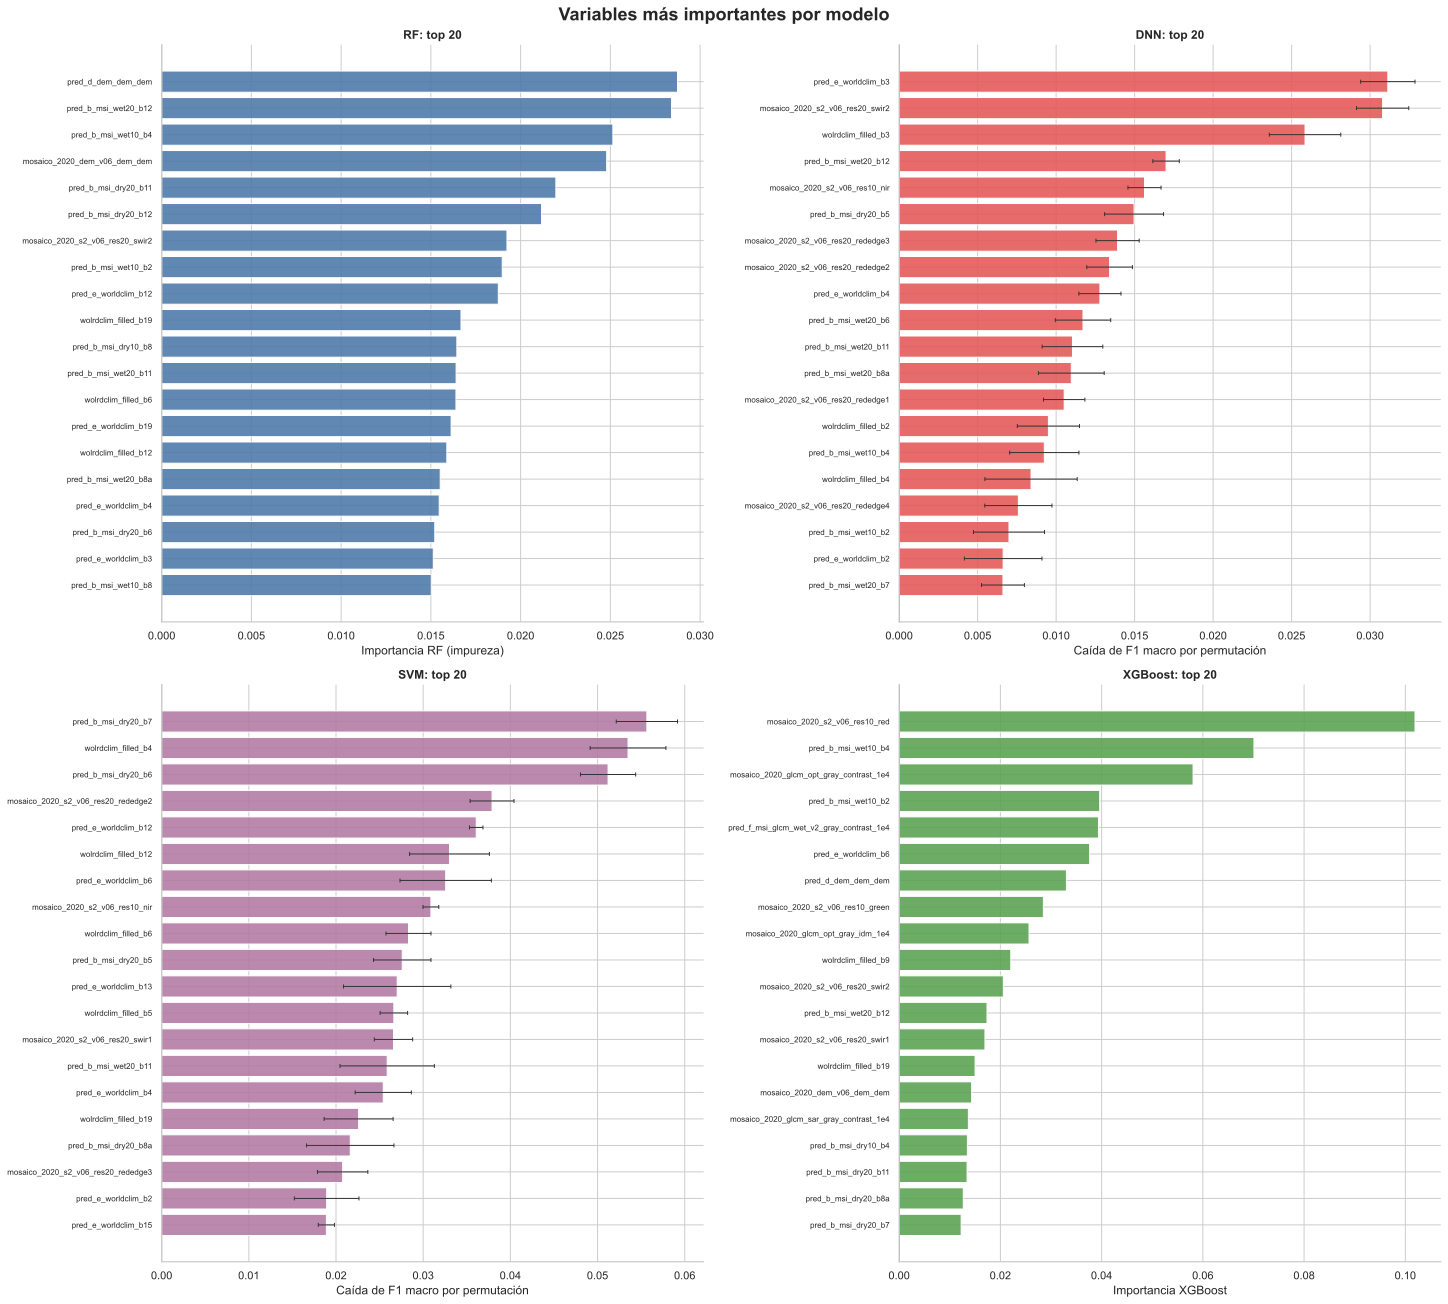

In [5]:
COLORS = {"RF": "#4C78A8", "DNN": "#E45756", "SVM": "#B279A2", "XGBoost": "#59A14F"}
X_LABELS = {
    "RF": "Importancia RF (impureza)",
    "DNN": "Caída de F1 macro por permutación",
    "SVM": "Caída de F1 macro por permutación",
    "XGBoost": "Importancia XGBoost",
}


def top_features(model: str, n: int = TOP_N) -> pd.DataFrame:
    return (
        importance.loc[importance["model"] == model]
        .nlargest(n, "importance")
        .sort_values("importance", ascending=True)
    )


fig, axes = plt.subplots(2, 2, figsize=(20, 18), constrained_layout=True)
for ax, model in zip(axes.ravel(), ["RF", "DNN", "SVM", "XGBoost"]):
    data = top_features(model)
    error = data["uncertainty"] if model in {"DNN", "SVM"} else None
    ax.barh(
        data["feature"],
        data["importance"],
        xerr=error,
        color=COLORS[model],
        alpha=0.88,
        error_kw={"ecolor": "#333333", "capsize": 2, "elinewidth": 1},
    )
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set_title(f"{model}: top {len(data)}", fontweight="bold")
    ax.set_xlabel(X_LABELS[model])
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)
    sns.despine(ax=ax)

fig.suptitle("Variables más importantes por modelo", fontsize=18, fontweight="bold")
save_figure(fig, "top20_importance_by_model")
plt.show()


In [6]:
top_table = (
    importance.sort_values(["model", "rank"])
    .groupby("model", as_index=False, group_keys=False)
    .head(10)[["model", "rank", "feature", "importance", "uncertainty"]]
)
display(top_table)
top_table.to_csv(TABLES_DIR / "top10_feature_importance_by_model.csv", index=False)


,model,rank,feature,importance,uncertainty
96,DNN,1.0,pred_e_worldclim_b3,0.031129,0.001731
97,DNN,2.0,mosaico_2020_s2_v06_res20_swir2,0.030797,0.001664
98,DNN,3.0,wolrdclim_filled_b3,0.025856,0.002275
99,DNN,4.0,pred_b_msi_wet20_b12,0.017003,0.000842
100,DNN,5.0,mosaico_2020_s2_v06_res10_nir,0.015630,0.001055
101,DNN,6.0,pred_b_msi_dry20_b5,0.014965,0.001877
102,DNN,7.0,mosaico_2020_s2_v06_res20_rededge3,0.013914,0.001377
103,DNN,8.0,mosaico_2020_s2_v06_res20_rededge2,0.013405,0.001453
104,DNN,9.0,pred_e_worldclim_b4,0.012790,0.001342
105,DNN,10.0,pred_b_msi_wet20_b6,0.011712,0.001764


## 4. Comparación relativa entre modelos

Para evitar comparar unidades incompatibles, cada importancia se divide por el máximo del mismo modelo. El valor 1 identifica la variable líder dentro de cada algoritmo.

RuntimeError: FT_Render_Glyph (ft2font_wrapper.cpp line 1934) failed with error 0x62: raster overflow

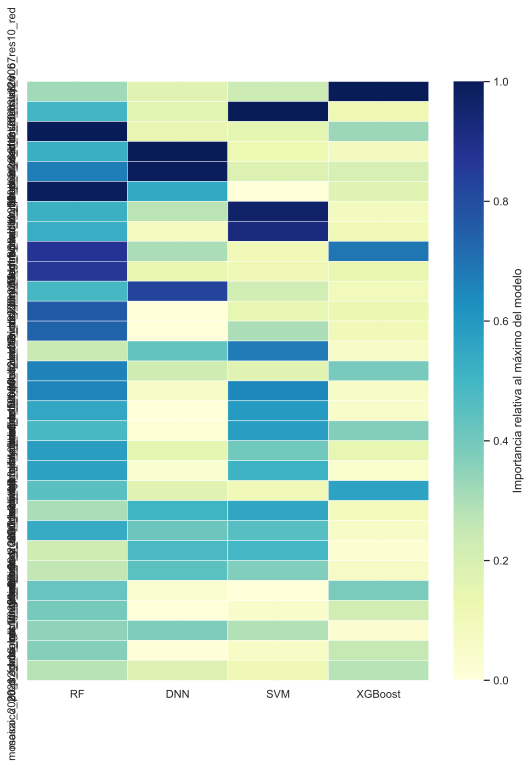

In [7]:
top_union = set(
    importance.sort_values(["model", "rank"])
    .groupby("model", group_keys=False)
    .head(UNION_TOP_N)["feature"]
)
relative_matrix = (
    importance.loc[importance["feature"].isin(top_union)]
    .pivot(index="feature", columns="model", values="relative_to_model_max")
    .reindex(columns=["RF", "DNN", "SVM", "XGBoost"])
)
relative_matrix = relative_matrix.loc[
    relative_matrix.max(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(9, max(8, 0.36 * len(relative_matrix))))
sns.heatmap(
    relative_matrix,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Importancia relativa al máximo del modelo"},
    ax=ax,
)
ax.set_title(
    f"Unión de las {UNION_TOP_N} variables principales de cada modelo",
    fontweight="bold",
)
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "relative_importance_top_union")
plt.show()

relative_matrix.to_csv(TABLES_DIR / "relative_importance_top_union.csv")


## 5. Concordancia de rankings

La correlación de Spearman y el solapamiento Jaccard son descriptivos: indican si los modelos priorizan variables similares, pero no vuelven equivalentes los métodos de importancia.

RuntimeError: FT_Render_Glyph (ft2font_wrapper.cpp line 1934) failed with error 0x62: raster overflow

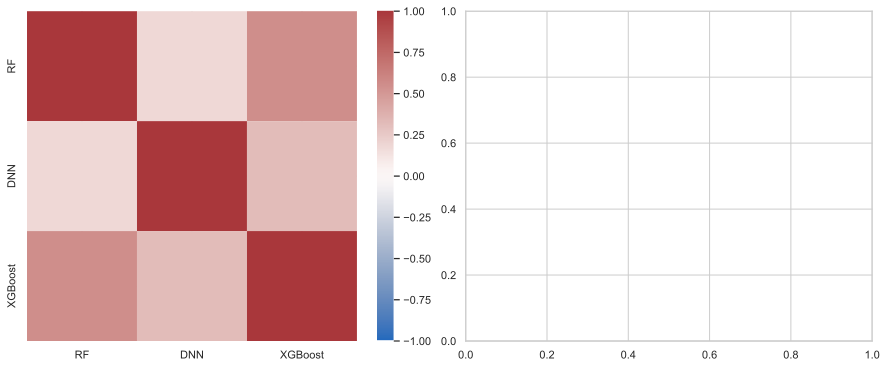

In [ ]:
importance_wide = importance.pivot(index="feature", columns="model", values="importance").reindex(
    columns=["RF", "DNN", "SVM", "XGBoost"]
)
spearman = importance_wide.corr(method="spearman")

top_sets = {
    model: set(
        importance.loc[importance["model"] == model]
        .nlargest(TOP_N, "importance")["feature"]
    )
    for model in ["RF", "DNN", "SVM", "XGBoost"]
}
jaccard = pd.DataFrame(index=top_sets, columns=top_sets, dtype=float)
for model_a, set_a in top_sets.items():
    for model_b, set_b in top_sets.items():
        jaccard.loc[model_a, model_b] = len(set_a & set_b) / len(set_a | set_b)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.heatmap(
    spearman,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Correlación de Spearman\n(todas las variables)", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    jaccard,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    ax=axes[1],
)
axes[1].set_title(f"Solapamiento Jaccard\n(top {TOP_N})", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

save_figure(fig, "importance_rank_agreement")
plt.show()

spearman.to_csv(TABLES_DIR / "importance_spearman_correlation.csv")
jaccard.to_csv(TABLES_DIR / "importance_top20_jaccard.csv")


## 6. Diagnóstico complementario: coeficientes de la SVM lineal

La SVM Nyström-RBF seleccionada ya aparece en los gráficos principales mediante importancia por permutación. Sus coeficientes pertenecen a 300 componentes de aproximación del kernel y no tienen una correspondencia directa componente–predictor original. La siguiente gráfica usa la SVM lineal y resume el valor absoluto de los coeficientes entre clases; debe reportarse únicamente como análisis complementario.

Aviso: no se pudo rasterizar svm_linear_top20_coefficients.png: FT_Render_Glyph (ft2font_wrapper.cpp line 1934) failed with error 0x62: raster overflow
La versión SVG sí quedó guardada en C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\data\processed\a4_model_feature_importance\plots\svm_linear_top20_coefficients.svg.


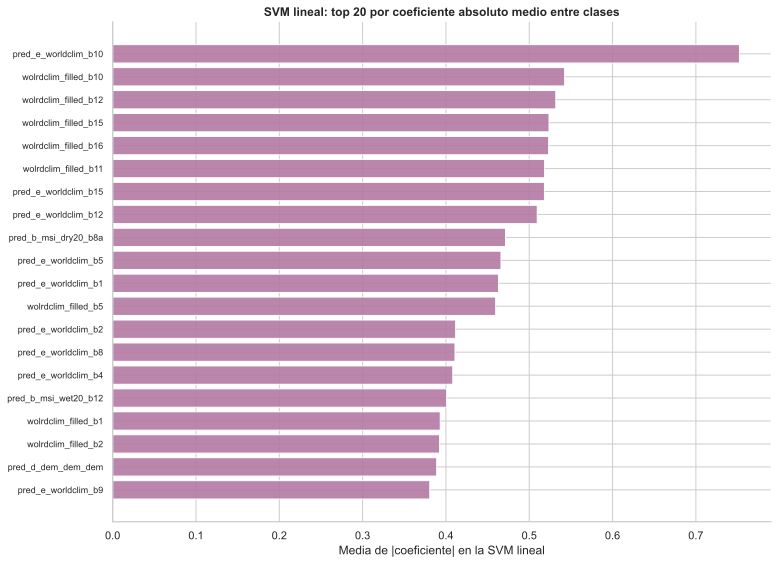

In [ ]:
svm_coefficients = pd.read_csv(PATHS["SVM_lineal"])
svm_original = svm_coefficients.loc[
    svm_coefficients["coefficient_space"].eq("original_feature")
].copy()

svm_summary = (
    svm_original.groupby("feature", as_index=False)
    .agg(
        mean_abs_coefficient=("abs_coefficient", "mean"),
        max_abs_coefficient=("abs_coefficient", "max"),
    )
    .sort_values("mean_abs_coefficient", ascending=False)
)
svm_top = svm_summary.head(TOP_N).sort_values("mean_abs_coefficient")

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    svm_top["feature"],
    svm_top["mean_abs_coefficient"],
    color="#B279A2",
    alpha=0.9,
)
ax.set_title(
    f"SVM lineal: top {TOP_N} por coeficiente absoluto medio entre clases",
    fontweight="bold",
)
ax.set_xlabel("Media de |coeficiente| en la SVM lineal")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "svm_linear_top20_coefficients")
plt.show()

svm_summary.to_csv(TABLES_DIR / "svm_linear_feature_coefficient_summary.csv", index=False)


RuntimeError: FT_Render_Glyph (ft2font_wrapper.cpp line 1934) failed with error 0x62: raster overflow

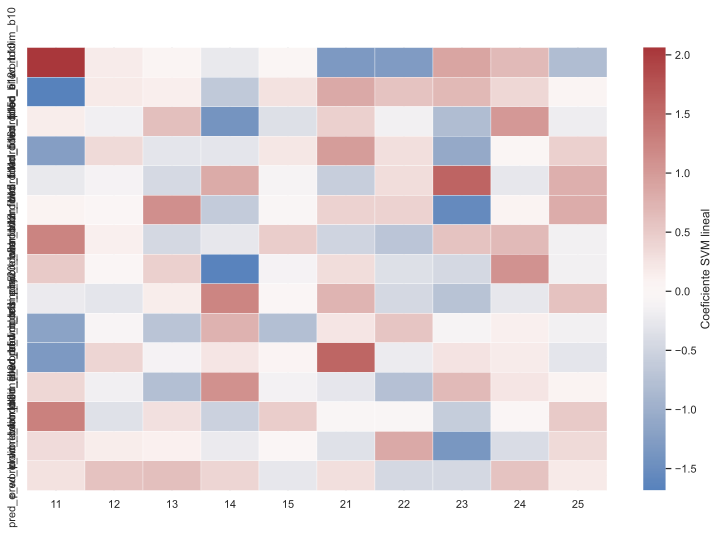

In [ ]:
svm_top_features = svm_summary.head(15)["feature"].tolist()
svm_class_matrix = (
    svm_original.loc[svm_original["feature"].isin(svm_top_features)]
    .pivot(index="feature", columns="class_id", values="coefficient")
    .reindex(svm_top_features)
)

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(
    svm_class_matrix,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Coeficiente SVM lineal"},
    ax=ax,
)
ax.set_title("SVM lineal: signo y magnitud por clase", fontweight="bold")
ax.set_xlabel("Clase")
ax.set_ylabel("")
fig.tight_layout()
save_figure(fig, "svm_linear_coefficients_by_class")
plt.show()


## 7. Archivos generados

In [ ]:
generated = sorted(
    [*PLOTS_DIR.glob("*.png"), *PLOTS_DIR.glob("*.svg"), *TABLES_DIR.glob("*.csv")]
)
display(
    pd.DataFrame(
        {
            "archivo": [path.relative_to(REPO_ROOT) for path in generated],
            "tamaño_kb": [round(path.stat().st_size / 1024, 1) for path in generated],
        }
    )
)


,archivo,tamaño_kb
0,data\processed\a4_model_feature_importance\plots\importance_rank_agreement.svg,59.6
1,data\processed\a4_model_feature_importance\plots\relative_importance_top_union.svg,146.4
2,data\processed\a4_model_feature_importance\plots\svm_linear_coefficients_by_class.svg,104.2
3,data\processed\a4_model_feature_importance\plots\svm_linear_top20_coefficients.svg,80.6
4,data\processed\a4_model_feature_importance\plots\top20_importance_by_model.svg,208.2
5,data\processed\a4_model_feature_importance\tables\importance_spearman_correlation.csv,0.2
6,data\processed\a4_model_feature_importance\tables\importance_top20_jaccard.csv,0.1
7,data\processed\a4_model_feature_importance\tables\model_feature_importance_harmonized.csv,32.2
8,data\processed\a4_model_feature_importance\tables\relative_importance_top_union.csv,2.1
9,data\processed\a4_model_feature_importance\tables\svm_linear_feature_coefficient_summary.csv,6.1
